# Kaggle house price prediction quest  by 김민수

기본 세팅 : 라이브러리 호출 및 데이터 로드

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/data')

train_data_path = os.path.join(data_dir, 'train.csv')
sub_data_path = os.path.join(data_dir, 'test.csv')  

Train 데이터 null 여부 체크

<Axes: >

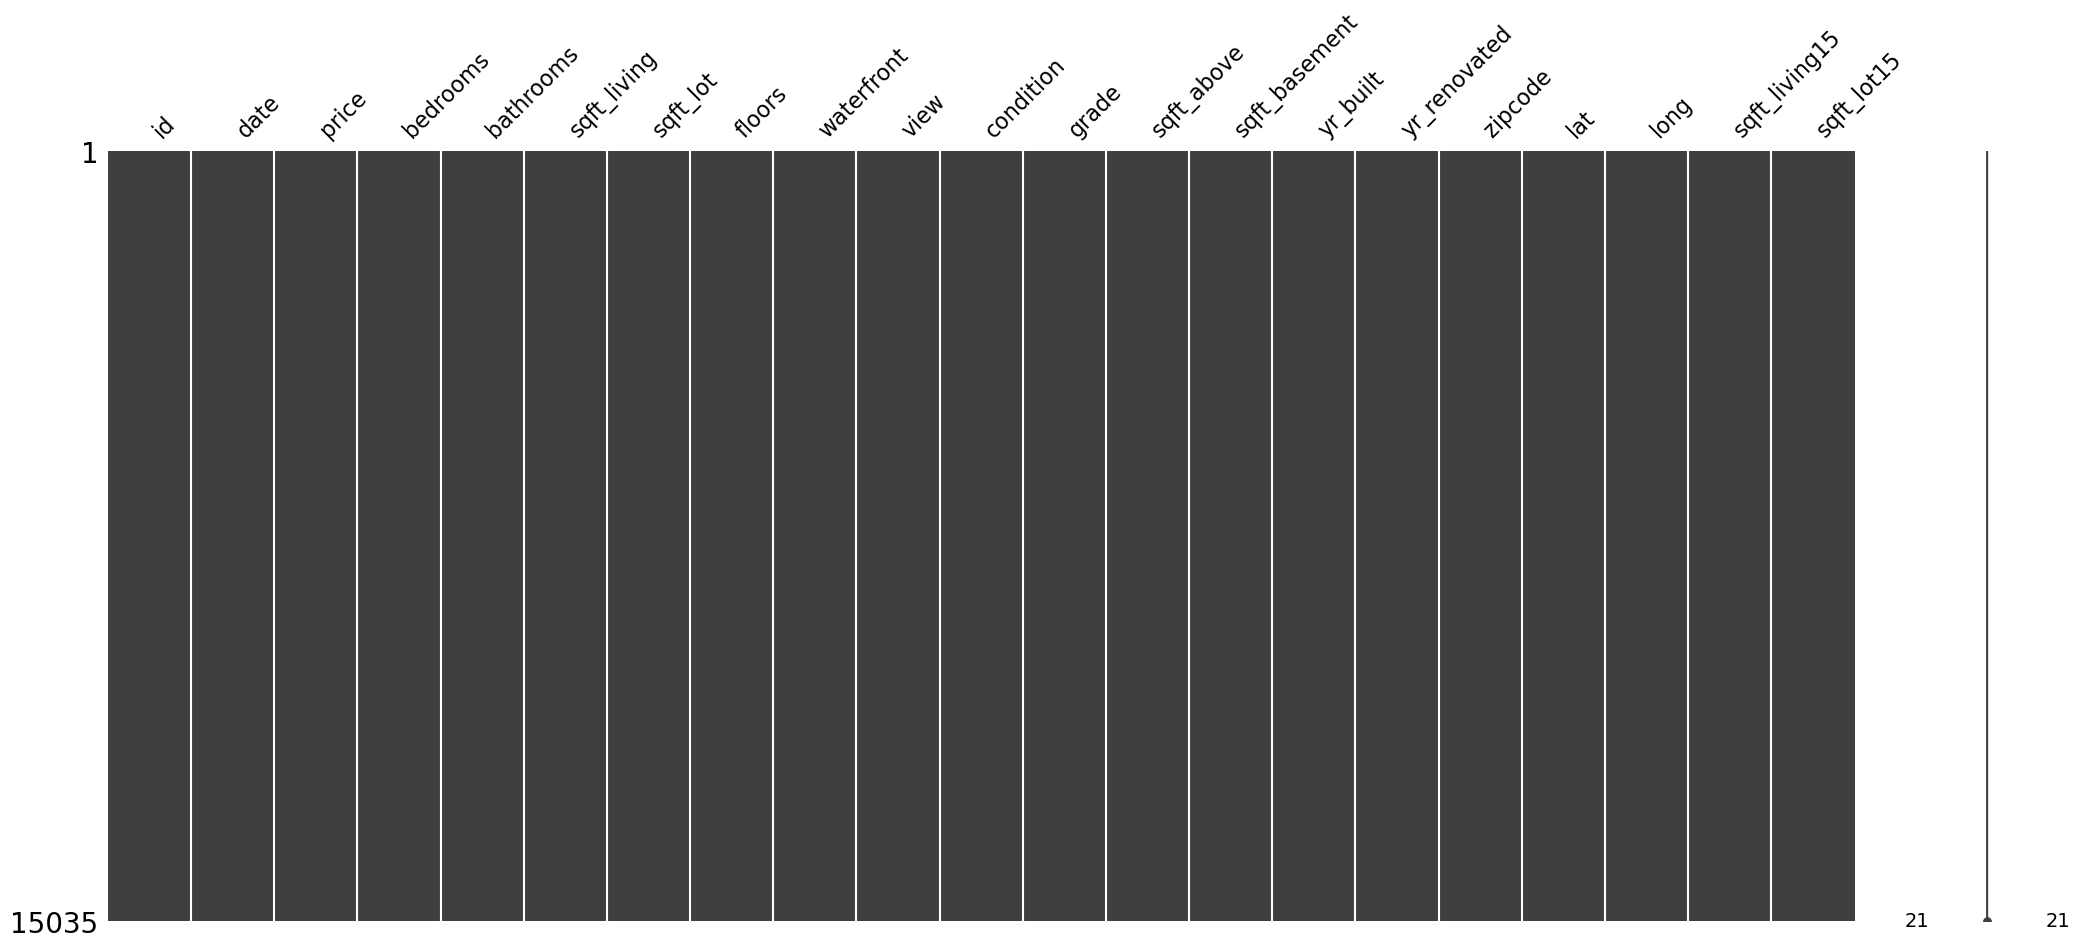

In [31]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(sub_data_path)
msno.matrix(train)

데이터 전처리

1. date 정보에서 년월 정보만 가져오기
2. 좌우 대칭이 아닌 그래프 데이터들의 정규분포화 작업
3. 피처 추가: 면적 합산값, 면적 비율, total area, area ratio, house age, renovated, 지하 비율, 주위집들과 비교, 상위등급 여부(10이상), 침실당 욕실 수
4. zipcode를 숫자가 아닌 카테고리 타입으로 변경
5. 불필요한 정보 칼럼 삭제

In [32]:

train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']
for c in skew_columns:
    train[c] = np.log1p(train[c].values)
    test[c] = np.log1p(test[c].values)

train['total_area'] = train['sqft_living'] + train['sqft_lot']    #면적 합산 지표
train['area_ratio'] = train['sqft_living'] / train['sqft_lot']    #면적 비율
train['house_age'] = 2015 - train['yr_built']                         #집 연령 계산 (2015년 기준)
train['renovated'] = (train['yr_renovated'] > 0).astype(int)          #renovation 여부
train['basement_ratio'] = train['sqft_basement'] / train['sqft_living']   # 지하 비율
train['living15_ratio']    = train['sqft_living'] / train['sqft_living15']   #주위 집과 비교
train['bath_per_bed']      = train['bathrooms'] / (train['bedrooms'] + 1)    # 침실당 욕실 수
train['high_grade']        = (train['grade'] >= 10).astype(int)       #상위등급
train['zipcode'] = train['zipcode'].astype('category')            #zip 정보를 category로 변경

#Test 데이터에도 적용
test['total_area'] = test['sqft_living'] + test['sqft_lot']
test['area_ratio']  = test['sqft_living']  / test['sqft_lot']
test['house_age'] = 2015 - test['yr_built']     
test['renovated'] = (test['yr_renovated'] > 0).astype(int)
test['basement_ratio'] = test['sqft_basement'] / test['sqft_living']   
test['living15_ratio']    = test['sqft_living'] / test['sqft_living15']   
test['bath_per_bed']      = test['bathrooms'] / (test['bedrooms'] + 1)   
test['high_grade']        = (test['grade'] >= 10).astype(int)       
test['zipcode']  = test['zipcode'].astype('category')

y = train['price']
del train['price']

del train['id']
del test['id']


학습 모델 함수 정의
- XGBoost, LightGBM, RandomForest Regressor, GBoost 모델 사용

Grid Search 설정
- 모델 평가 지표로 RMSE 적용

In [33]:
from sklearn.model_selection import GridSearchCV


def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=5):
    # GridSearchCV 모델로 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, scoring='neg_mean_squared_error', \
                              cv=5, verbose=verbose, n_jobs=n_jobs)

    # 모델 fitting
    grid_model.fit(train, y)

    # 결과값 저장
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']

    # 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['score'] = score

    # RMSLE 값 계산 후 정렬
    results['RMSLE'] = np.sqrt(-1 * results['score'])
    results = results.sort_values('RMSLE')

    return results

학습용 파라미터 설정
- grid search 설정: 트리의 횡적/종적 한도 , Leave 수량, Learning Rate 설정
- price 값에 log 함수 적용
- 최적 파라미터로 모델 재학습

In [27]:
param_grid = {
    'n_estimators': [700, 900, 1100],
    'max_depth': [8, 12, 15],
    'learning_rate': [0.06, 0.05, 0.04],
    'num_leaves' : [12, 15]
}

y_log = np.log1p(y)

model = LGBMRegressor(random_state=random_state)
param_gained = my_GridSearch(model, train, y_log, param_grid, verbose=10, n_jobs=5)

best = param_gained.iloc[0]
print(best)

# 최적 파라미터로 모델 재학습
model = LGBMRegressor(
    max_depth    = int(best['max_depth']),
    n_estimators = int(best['n_estimators']),
    learning_rate= best['learning_rate'],
    num_leaves   = int(best['num_leaves']),
    random_state = random_state
)
model.fit(train, y_log)



Fitting 5 folds for each of 54 candidates, totalling 270 fits

[LightGBM] [Info] Start training from score 13.050660
[CV 4/5; 72/81] END learning_rate=0.04, max_depth=12, n_estimators=900, num_leaves=18;, score=-0.026 total time=  10.7s
[CV 1/5; 74/81] START learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=15
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3523
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 27
[LightGBM] [Info] Start training from score 13.050187
[CV 1/5; 74/81] END learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=15;, score=-0.026 total time=   5.5s
[CV 1/5; 75/81] START learning_rate=0.04, max_depth=15, n_estimators=500, num_leaves=18
[LightGBM] [Info] Auto-choosing row-wise multi-threading, th

,boosting_type,'gbdt'
,num_leaves,12
,max_depth,8
,learning_rate,np.float64(0.05)
,n_estimators,1100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
파일 저장용 함수 설정

In [28]:

def save_submission(model, train, y_log, test, model_name, rmsle=best['RMSLE'].round(4)):
    model.fit(train, y_log)
    # prediction = model.predict(test)
    # prediction = np.expm1(prediction)
    prediction = np .expm1(model.predict(test))
    data_dir = '~/work/kaggle_kakr_housing/data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/harry_submission_{}_ver_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

print(param_gained.head())

    learning_rate  max_depth  n_estimators  num_leaves     score     RMSLE
22           0.05          8          1100          12 -0.025778  0.160556
28           0.05         12          1100          12 -0.025808  0.160649
34           0.05         15          1100          12 -0.025808  0.160649
53           0.04         15          1100          15 -0.025814  0.160666
20           0.05          8           900          12 -0.025818  0.160678


In [29]:
# 파일명 설정 및 저장 실행

save_submission(model, train, y_log, test, 'lgbm', rmsle='0.9')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3568
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 27
[LightGBM] [Info] Start training from score 13.048122
~/work/kaggle_kakr_housing/data/harry_submission_lgbm_ver_0.9.csv saved!


파일 제출 이후 화면 캡쳐: Private Score 11만점 이하 달성

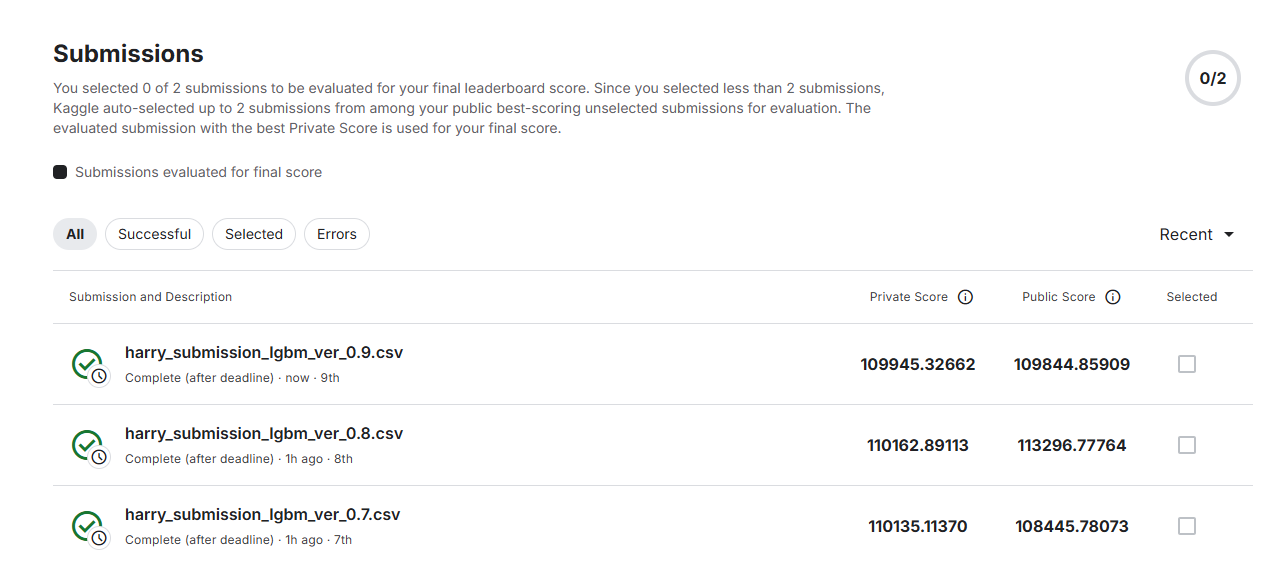
